# Cancer Cell Recognition using RNA Sequencing

## Importing Dependencies and Environment Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [4]:
#loading the dataset
ex = pd.read_csv('G2-TCGA-HNSC_EX.csv', header=0)
X = ex.iloc[:,1:] #dropping the first column

#loading the labels
y = pd.read_csv('G2-TCGA-HNSC_Label.csv', header=0)
y = y.iloc[:,0] #convert to a series or a single vector

print(f"Gene expression matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts().rename({0:'Healthy', 1:'Cancerous'}))

Gene expression matrix: (563, 35957)
Labels: (563,)

Class distribution:
0
Cancerous    520
Healthy       43
Name: count, dtype: int64


Dataset is inbalanced

## EDA

In [5]:
print("=" * 55)
print("DATASET: TCGA-HNSC Gene Expression (Head & Neck Cancer)")
print("=" * 55)

print(f"\nSamples (patients):     {X.shape[0]}")
print(f"Features (genes):       {X.shape[1]}")
print(f"Missing values:         {X.isnull().sum().sum()}")
print(f"Data type:              {X.dtypes.unique()[0]} (RNA-seq read counts)")

print(f"\nClass Distribution:")
counts = y.value_counts().rename({0: 'Healthy (0)', 1: 'Cancerous (1)'})
for label, count in counts.items():
    pct = count / len(y) * 100
    print(f"  {label}: {count} samples ({pct:.1f}%)")

DATASET: TCGA-HNSC Gene Expression (Head & Neck Cancer)

Samples (patients):     563
Features (genes):       35957
Missing values:         0
Data type:              int64 (RNA-seq read counts)

Class Distribution:
  Cancerous (1): 520 samples (92.4%)
  Healthy (0): 43 samples (7.6%)


Severe class imbalance (92% / 8%)

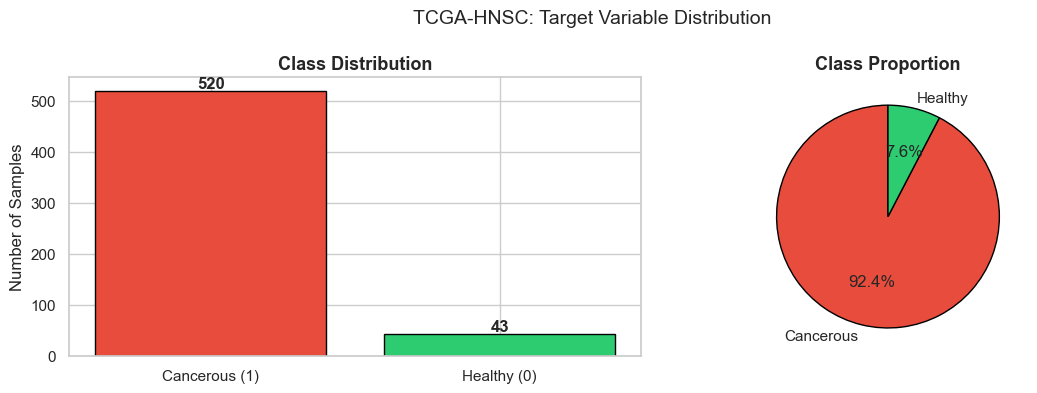

In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

#Bar Chart
counts = y.value_counts() #to get the count of healthy(0) vs cancerous(1)
axes[0].bar(['Cancerous (1)', 'Healthy (0)'],
            [counts[1], counts[0]],
            color = ["#e74c3c", "#2ecc71"], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')

for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie([counts[1], counts[0]],
            labels=['Cancerous', 'Healthy'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('TCGA-HNSC: Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()



Again we see high class inbalance. If we make a model that predicts cancerous always it will have a 92% accuracy, therefore we need to opt for other metrics like F1 score.

In [7]:
stats = X.describe().T  # gets the stats for each column and transpose so genes are rows

print("Summary Statistics (per gene across all samples):")
print(f"  Mean expression range:   {stats['mean'].min():.1f}  -  {stats['mean'].max():.1f}")
print(f"  Std dev range:           {stats['std'].min():.1f}  -  {stats['std'].max():.1f}")
print(f"  Min value:               {stats['min'].min():.0f}")
print(f"  Max value:               {stats['max'].max():.0f}")
print(f"\nGenes with zero mean (never expressed): {(stats['mean'] == 0).sum()}")
print(f"Genes with very low variance (std < 1):  {(stats['std'] < 1).sum()}")

Summary Statistics (per gene across all samples):
  Mean expression range:   0.0  -  7199.8
  Std dev range:           0.2  -  2391.3
  Min value:               0
  Max value:               20376

Genes with zero mean (never expressed): 0
Genes with very low variance (std < 1):  7381


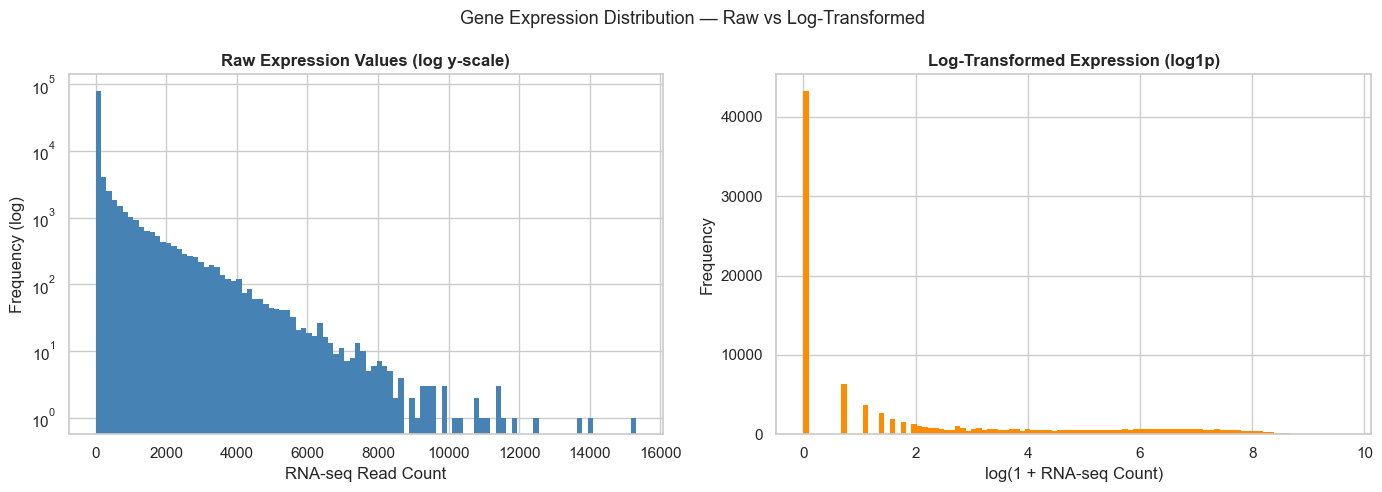

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts — sample 1000 random gene values for speed
sample_vals = X.values.flatten()
np.random.seed(42)
sample_vals = np.random.choice(sample_vals, size=100000, replace=False)

axes[0].hist(sample_vals, bins=100, color='steelblue',
             edgecolor='none', log=True)
axes[0].set_title('Raw Expression Values (log y-scale)', fontweight='bold')
axes[0].set_xlabel('RNA-seq Read Count')
axes[0].set_ylabel('Frequency (log)')

# Log-transformed
log_vals = np.log1p(sample_vals)   # log1p = log(1+x), handles zeros
axes[1].hist(log_vals, bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Log-Transformed Expression (log1p)', fontweight='bold')
axes[1].set_xlabel('log(1 + RNA-seq Count)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Gene Expression Distribution — Raw vs Log-Transformed',
             fontsize=13)
plt.tight_layout()
plt.show()

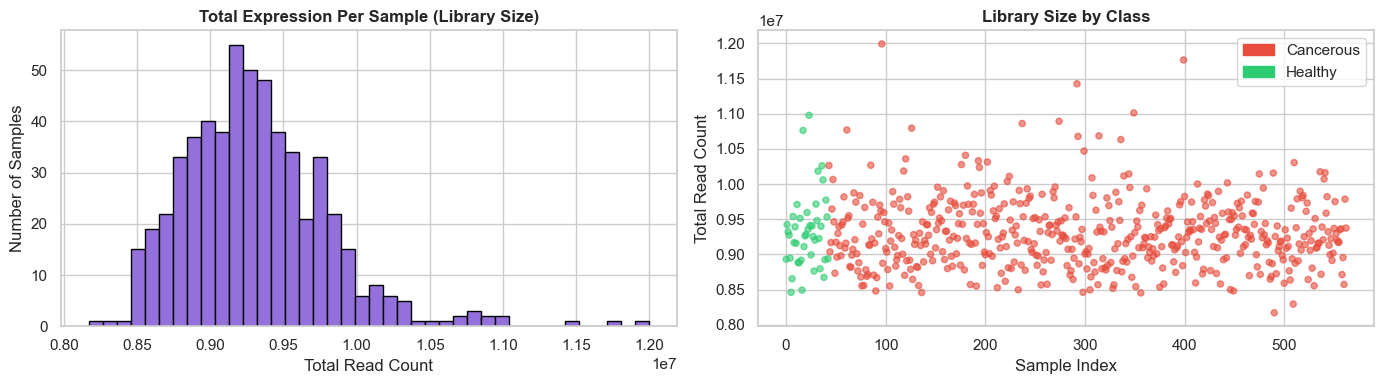

Mean library size:   9,306,869
Std library size:    497,064
Min library size:    8,170,379
Max library size:    11,994,100


In [9]:
sample_totals = X.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_totals, bins=40, color='mediumpurple', edgecolor='black')
axes[0].set_title('Total Expression Per Sample (Library Size)', fontweight='bold')
axes[0].set_xlabel('Total Read Count')
axes[0].set_ylabel('Number of Samples')

# Colored by class
colors = y.map({0: '#2ecc71', 1: '#e74c3c'})
axes[1].scatter(range(len(sample_totals)), sample_totals,
                c=colors, alpha=0.6, s=20)
axes[1].set_title('Library Size by Class', fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Total Read Count')

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Cancerous'),
          Patch(color='#2ecc71', label='Healthy')]
axes[1].legend(handles=legend)

plt.tight_layout()
plt.show()

print(f"Mean library size:   {sample_totals.mean():,.0f}")
print(f"Std library size:    {sample_totals.std():,.0f}")
print(f"Min library size:    {sample_totals.min():,.0f}")
print(f"Max library size:    {sample_totals.max():,.0f}")

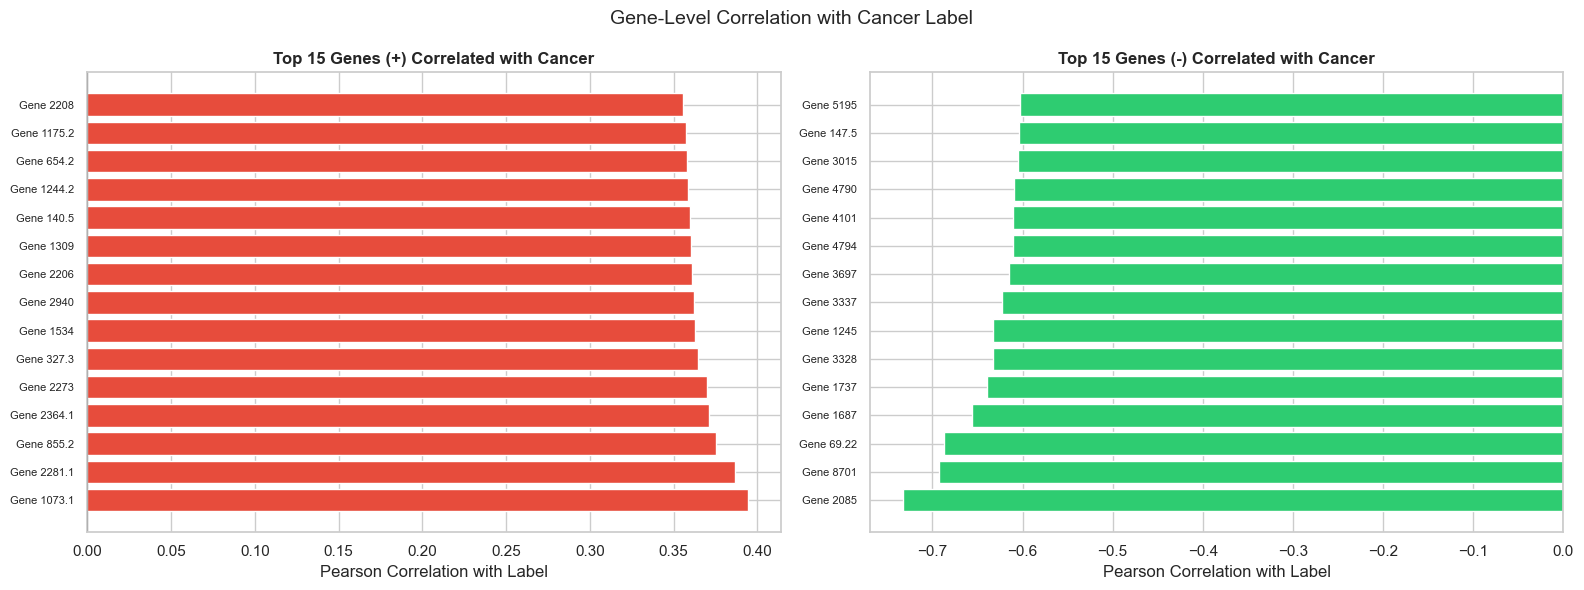

Strongest positive correlation: 0.394 (Gene 1073.1)
Strongest negative correlation: -0.733 (Gene 2085)


In [10]:
# Compute correlation of each gene with the label
correlations = X.apply(lambda col: col.corr(y))

# Sort by absolute correlation strength
top_pos = correlations.nlargest(15)    # most positively correlated
top_neg = correlations.nsmallest(15)   # most negatively correlated
top_genes = pd.concat([top_pos, top_neg])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive correlations
axes[0].barh(range(len(top_pos)), top_pos.values, color='#e74c3c')
axes[0].set_yticks(range(len(top_pos)))
axes[0].set_yticklabels([f'Gene {g}' for g in top_pos.index], fontsize=8)
axes[0].set_title('Top 15 Genes (+) Correlated with Cancer',
                  fontweight='bold')
axes[0].set_xlabel('Pearson Correlation with Label')
axes[0].axvline(0, color='black', linewidth=0.8)

# Negative correlations
axes[1].barh(range(len(top_neg)), top_neg.values, color='#2ecc71')
axes[1].set_yticks(range(len(top_neg)))
axes[1].set_yticklabels([f'Gene {g}' for g in top_neg.index], fontsize=8)
axes[1].set_title('Top 15 Genes (-) Correlated with Cancer',
                  fontweight='bold')
axes[1].set_xlabel('Pearson Correlation with Label')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Gene-Level Correlation with Cancer Label', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Strongest positive correlation: {top_pos.max():.3f} (Gene {top_pos.idxmax()})")
print(f"Strongest negative correlation: {top_neg.min():.3f} (Gene {top_neg.idxmin()})")

Gene-level correlation analysis revealed that negatively correlated genes showed stronger associations (up to -0.72) than positively correlated ones (+0.40), suggesting that gene silencing — potentially tumor suppressor downregulation — may be more diagnostically informative than oncogene upregulation in this dataset.

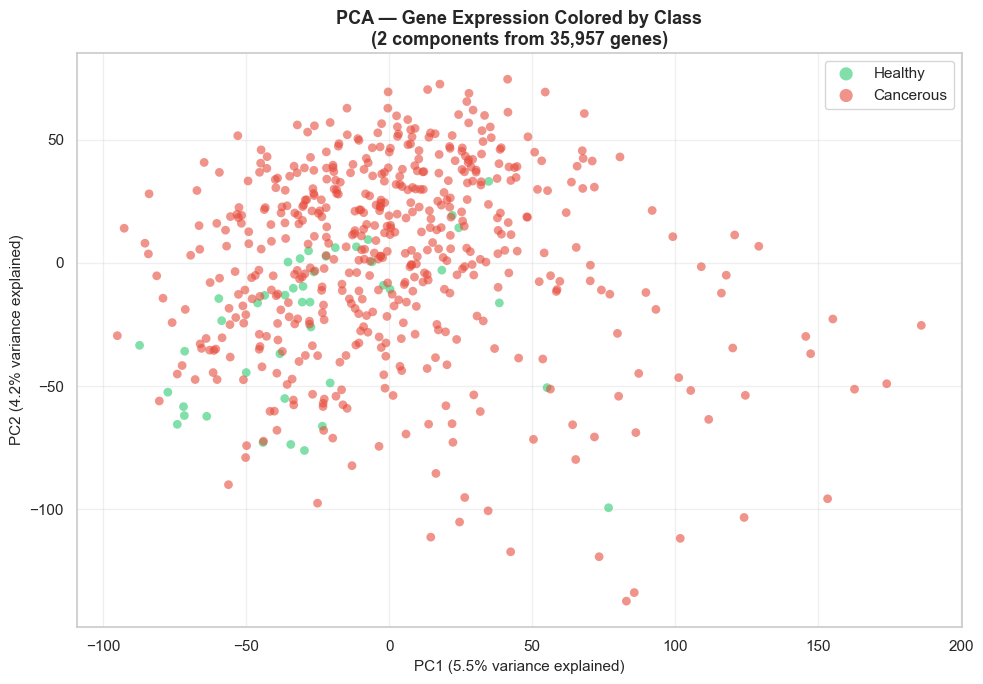

PC1 explains: 5.5% of variance
PC2 explains: 4.2% of variance
Total (2 PCs): 9.7% of variance

Observation: Look at whether the two classes form distinct clusters.


In [11]:
# PCA Visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Log-transform first (same as we'll do in preprocessing)
X_log = np.log1p(X)

# Step 2: Standardize (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Step 3: Reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: '#2ecc71', 1: '#e74c3c'}
labels_map = {0: 'Healthy', 1: 'Cancerous'}

for cls in [0, 1]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=labels_map[cls],
               alpha=0.6, s=40, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_title('PCA — Gene Expression Colored by Class\n(2 components from 35,957 genes)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

total_var = sum(pca.explained_variance_ratio_) * 100
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total (2 PCs): {total_var:.1f}% of variance")
print(f"\nObservation: Look at whether the two classes form distinct clusters.")

### EDA Conclusions

| Finding | What It Means |
|---------|--------------|
| 92% / 8% class split | Severe imbalance — F1 and ROC-AUC are our primary metrics |
| Raw counts right-skewed | Log1p transformation required |
| Spike at zero after log1p | Many genes biologically inactive — remove via variance filtering |
| Library sizes consistent | No sequencing depth bias between classes |
| PCA shows partial overlap in 2D | Signal is distributed across many genes, not 1-2 dominant ones |
| Negative gene correlations stronger (-0.72) | Gene silencing more diagnostically informative than overexpression |
| Most genes near-zero correlation | Confirms need for aggressive feature selection |

# Preprocessing

## Log1p Transformation
- We saw in EDA that raw counts are heavily right-skewed. 
- Log1p compresses large values and spreads small ones, making the distribution friendlier for models to learn from.

In [12]:
X_log = np.log1p(X)

print("Log1p transformation applied.")
print(f"Before — Max value: {X.values.max():,}")
print(f"After  — Max value: {X_log.values.max():.2f}")
print(f"Before — Mean:      {X.values.mean():.2f}")
print(f"After  — Mean:      {X_log.values.mean():.2f}")

Log1p transformation applied.
Before — Max value: 20,376
After  — Max value: 9.92
Before — Mean:      258.83
After  — Mean:      2.19


## Remove Low-Variance Genes
A gene that barely changes across patients carries no useful signal for classification. 
VarianceThreshold removes any feature whose variance falls below a threshold.

After log1p, values range roughly 0–10. A variance of 0.1 means the gene's expression barely moves across all 563 patients — useless for distinguishing cancer from healthy.

In [13]:
from sklearn.feature_selection import VarianceThreshold

before = X_log.shape[1]

selector = VarianceThreshold(threshold=0.1)
X_var = selector.fit_transform(X_log)

after = X_var.shape[1]
removed = before - after

print(f"Genes before variance filter: {before:,}")
print(f"Genes after variance filter:  {after:,}")
print(f"Genes removed:                {removed:,} ({removed/before*100:.1f}%)")

Genes before variance filter: 35,957
Genes after variance filter:  28,950
Genes removed:                7,007 (19.5%)


## Feature Selection (Top Correlated Genes)
Even after variance filtering we likely still have thousands of genes. We keep only the top K genes that are most correlated with the label. 
This directly tackles the curse of dimensionality (35,957 features, only 563 samples).


In [14]:
# Select Top 500 Genes by Correlation

# Get column names that survived variance filtering
surviving_genes = X_log.columns[selector.get_support()]
X_var_df = pd.DataFrame(X_var, columns=surviving_genes)

# Recompute correlations on variance-filtered set
correlations_filtered = X_var_df.apply(lambda col: col.corr(y))

# Keep top 500 by absolute correlation
top500 = correlations_filtered.abs().nlargest(500).index
X_selected = X_var_df[top500]

print(f"Genes after variance filter:     {X_var_df.shape[1]:,}")
print(f"Genes after correlation filter:  {X_selected.shape[1]}")
print(f"Final feature matrix shape:      {X_selected.shape}")
print(f"\nTop 5 selected genes by correlation strength:")
print(correlations_filtered[top500].abs().nlargest(5))

Genes after variance filter:     28,950
Genes after correlation filter:  500
Final feature matrix shape:      (563, 500)

Top 5 selected genes by correlation strength:
0.1687    0.679071
1.123     0.654943
14        0.651584
29.68     0.649205
6.81      0.646494
dtype: float64


We chose 500 as an arbitrary number, we can tune it like a hyperparameter to reduce overfitting later if needed

## Splitting Training and Testing
We will use stratified splitting because of highly skewed classes. We only have 43 healthy samples so stratified can ensure the ratio survives.


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts().rename({0:'Healthy', 1:'Cancerous'}))
print(f"\nTest class distribution:")
print(y_test.value_counts().rename({0:'Healthy', 1:'Cancerous'}))

Training set:   450 samples
Test set:       113 samples

Training class distribution:
0
Cancerous    416
Healthy       34
Name: count, dtype: int64

Test class distribution:
0
Cancerous    104
Healthy        9
Name: count, dtype: int64


## Scaling
Why: After all filtering, we scale each feature to mean=0, std=1. Neural networks and distance-based models are sensitive to feature scale — a gene with values 0-9 shouldn't dominate a gene with values 0-2 just because of magnitude.
Important: We fit the scaler only on training data and apply it to test data. If we fit on both, we'd be leaking test information into training — a common mistake that inflates results.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    # note: transform only, not fit_transform

print("StandardScaler applied.")
print(f"\nTraining set — Mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training set — Std  (should be ~1): {X_train_scaled.std():.4f}")
print(f"Test set     — Mean (slightly off is normal): {X_test_scaled.mean():.4f}")
print(f"Test set     — Std  (slightly off is normal): {X_test_scaled.std():.4f}")
print(f"\nFinal data ready for modeling:")
print(f"  X_train: {X_train_scaled.shape}")
print(f"  X_test:  {X_test_scaled.shape}")

StandardScaler applied.

Training set — Mean (should be ~0): 0.0000
Training set — Std  (should be ~1): 1.0000
Test set     — Mean (slightly off is normal): 0.0138
Test set     — Std  (slightly off is normal): 0.9725

Final data ready for modeling:
  X_train: (450, 500)
  X_test:  (113, 500)


## Model Training